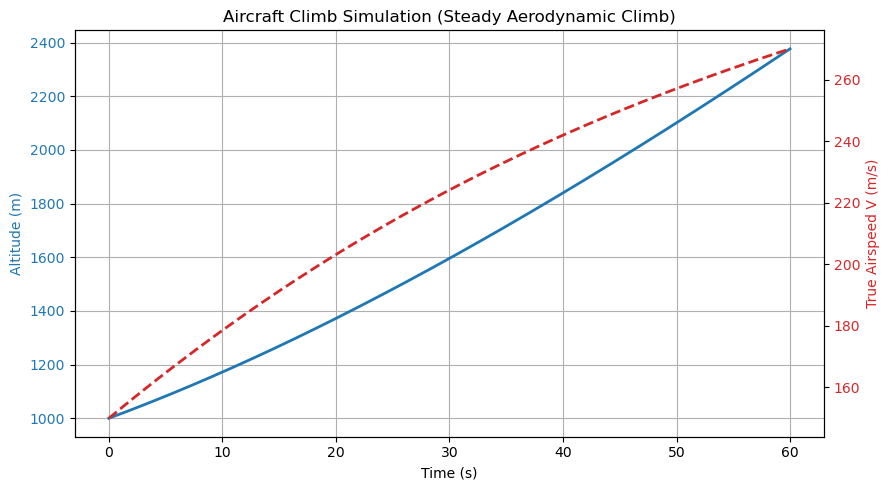

In [ ]:
import math
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Atmospheric & Aircraft parameters
Temp_0 = 288.15     
rho_0 = 1.225       
p_0 = 101325        
g = 9.81            
L = -0.0065         
R = 8.3144621       
M = 0.0289          

m = 10000           
wing_area = 25.0    
T_0 = 60000         
thro = 0.85         
theta = math.radians(6.0) 

lc = 0.5            
dc_0 = 0.02         
k = 0.05            
dc = dc_0 + k * lc**2

def ode_function(t, y):
    h, V = y
    # Correct ISA density calculation
    rho = rho_0 * (1.0 + L * h / Temp_0) ** (-g * M / (R * L) - 1.0)
    
    drag = 0.5 * rho * V**2 * wing_area * dc
    thrust = T_0 * thro
    
    dhdt = V * math.sin(theta)
    dVdt = (thrust - drag - m * g * math.sin(theta)) / m
    return [dhdt, dVdt]

# Initial conditions: h(0) = 1000 m, V(0) = 150 m/s
y0 = [1000.0, 150.0]
t_span = (0, 60) # 60 seconds climb

sol = solve_ivp(ode_function, t_span, y0, method='RK45', dense_output=True)
t_eval = np.linspace(t_span[0], t_span[1], 200)
sol_eval = sol.sol(t_eval)

altitude = sol_eval[0]
velocity = sol_eval[1]

# Plot with twin axes
fig, ax1 = plt.subplots(figsize=(9, 5))

color = 'tab:blue'
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Altitude (m)', color=color)
ax1.plot(t_eval, altitude, color=color, linewidth=2, label='Altitude h(t)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('True Airspeed V (m/s)', color=color)
ax2.plot(t_eval, velocity, color=color, linewidth=2, linestyle='--', label='Airspeed V(t)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Aircraft Climb Simulation (Steady Aerodynamic Climb)')
fig.tight_layout()
plt.show()

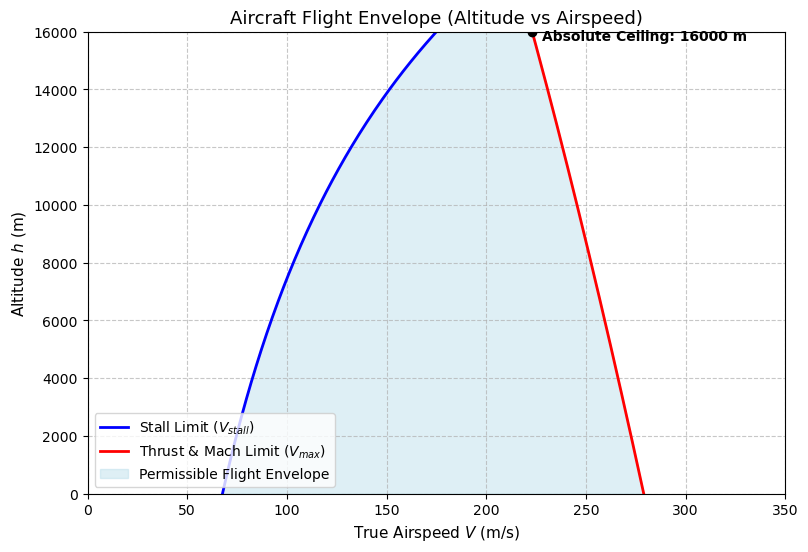

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Parameters
m = 10000.0          
g = 9.81
W = m * g            
wing_area = 25.0     
dc_0 = 0.02          
k = 0.05             
CL_max = 1.4         
T_max_sl = 60000.0   
M_MO = 0.82         

# Atmosphere constants
rho_0 = 1.225
Temp_0 = 288.15
L = -0.0065
R = 8.3144621
M_air = 0.0289
gamma = 1.4
R_spec = 287.05

def get_atmosphere(h):
    T_k = Temp_0 + L * h
    rho = rho_0 * (T_k / Temp_0) ** (-g * M_air / (R * L) - 1.0)
    a = math.sqrt(gamma * R_spec * T_k)  # Speed of sound
    return rho, a

h_vals = np.linspace(0, 16000, 200)
v_stall_list = []
v_max_list = []
valid_altitudes = []

# Minimum thrust required for level flight at (L/D)_max
D_min = 2 * math.sqrt(dc_0 * k) * W

for h in h_vals:
    rho, a = get_atmosphere(h)
    
    # Stall speed limit 
    v_stall = math.sqrt(2 * W / (rho * wing_area * CL_max))
    
    # Turbofan thrust lapse with altitude: T(h) = T_0 * (rho/rho_0)^0.8
    T_avail = T_max_sl * (rho / rho_0)**0.8
    
    # If thrust is less than minimum possible drag, aircraft cannot sustain level flight
    if T_avail < D_min:
        break
        
    # Solve level flight force balance: 0.5*rho*S*dc_0*V^4 - T*V^2 + 2*k*W^2/(rho*S) = 0
    A = 0.5 * rho * wing_area * dc_0 #drag term coefficient
    B = -T_avail #thrust term coefficient
    C = 2 * k * W**2 / (rho * wing_area) #constant term coefficient
    
    discriminant = B**2 - 4 * A * C
    if discriminant < 0:
        break
        
    V2_high = (-B + math.sqrt(discriminant)) / (2 * A)
    v_thrust_max = math.sqrt(V2_high)
    
    # Transonic Mach limit
    v_mach_max = M_MO * a
    v_max = min(v_thrust_max, v_mach_max)
    
    if v_stall <= v_max:
        v_stall_list.append(v_stall)
        v_max_list.append(v_max)
        valid_altitudes.append(h)

# Plotting
plt.figure(figsize=(9, 6))
plt.plot(v_stall_list, valid_altitudes, 'b-', linewidth=2, label='Stall Limit ($V_{stall}$)')
plt.plot(v_max_list, valid_altitudes, 'r-', linewidth=2, label='Thrust & Mach Limit ($V_{max}$)')

# Fill operating flight envelope
plt.fill_betweenx(valid_altitudes, v_stall_list, v_max_list, color='lightblue', alpha=0.4, label='Permissible Flight Envelope')

ceiling = valid_altitudes[-1]
plt.plot(v_max_list[-1], ceiling, 'ko', markersize=6)
plt.text(v_max_list[-1] + 5, ceiling - 300, f'Absolute Ceiling: {ceiling:.0f} m', fontsize=10, fontweight='bold')

plt.xlabel('True Airspeed $V$ (m/s)', fontsize=11)
plt.ylabel('Altitude $h$ (m)', fontsize=11)
plt.title('Aircraft Flight Envelope (Altitude vs Airspeed)', fontsize=13)
plt.xlim(0, 350)
plt.ylim(0, 16000)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()